# RQ7: Does combining delivery-level features with aggregated match-context features improve prediction?

**Research Question:** Does combining delivery-level features with aggregated match-context features (cumulative runs, wickets lost, required run rate) improve prediction performance over using raw delivery features alone?

**Comparison:** Raw features vs Context-enriched features on `is_wicket` classification

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, precision_score, recall_score
from xgboost import XGBClassifier
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/ipl-complete-dataset-2008-2025-enhanced-edition/deliveries.csv')
df = df.sort_values(['match_id', 'innings', 'over', 'ball']).reset_index(drop=True)

def over_phase(o):
    if o <= 6: return 'Powerplay'
    elif o <= 15: return 'Middle'
    else: return 'Death'

df['over_phase'] = df['over'].apply(over_phase)
df['is_wicket_int'] = df['is_wicket'].astype(int)
df['is_extra'] = (df['extra_runs'] > 0).astype(int)
print(f'Dataset: {df.shape}')

Dataset: (134190, 21)


In [3]:
# ── Build Cumulative Context Features ──
df['cum_runs'] = df.groupby(['match_id', 'innings'])['total_runs'].cumsum() - df['total_runs']
df['cum_wickets'] = df.groupby(['match_id', 'innings'])['is_wicket_int'].cumsum() - df['is_wicket_int']
df['ball_number'] = df.groupby(['match_id', 'innings']).cumcount() + 1
df['run_rate_so_far'] = df.apply(
    lambda r: (r['cum_runs'] / (r['ball_number'] / 6)) if r['ball_number'] > 0 else 0, axis=1
)
df['wickets_remaining'] = 10 - df['cum_wickets']

print('Context features created:')
print(df[['match_id', 'innings', 'over', 'ball', 'cum_runs', 'cum_wickets', 'run_rate_so_far']].head(10))

Context features created:
  match_id  innings  over  ball  cum_runs  cum_wickets  run_rate_so_far
0    M0001        1     1     1         0            0         0.000000
1    M0001        1     1     2         2            0         6.000000
2    M0001        1     1     3         6            0        12.000000
3    M0001        1     1     4         6            1         9.000000
4    M0001        1     1     5         8            1         9.600000
5    M0001        1     1     6        15            1        15.000000
6    M0001        1     2     1        17            1        14.571429
7    M0001        1     2     2        18            1        13.500000
8    M0001        1     2     3        18            1        12.000000
9    M0001        1     2     4        20            1        12.000000


In [4]:
# ── Encode Categoricals ──
le = LabelEncoder()
for col in ['batting_team', 'bowling_team', 'over_phase']:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Feature sets
RAW_FEATURES = ['innings', 'over', 'ball', 'batting_team_enc', 'bowling_team_enc',
                'over_phase_enc', 'batsman_runs', 'extra_runs', 'is_extra']

CONTEXT_FEATURES = RAW_FEATURES + ['cum_runs', 'cum_wickets', 'run_rate_so_far', 'wickets_remaining', 'ball_number']

y = df['is_wicket_int']

print(f'Raw features: {len(RAW_FEATURES)}')
print(f'Context-enriched features: {len(CONTEXT_FEATURES)}')

Raw features: 9
Context-enriched features: 14


In [5]:
# ── Train and Compare ──
results = {}
feature_sets = {'Raw Features': RAW_FEATURES, 'Context-Enriched': CONTEXT_FEATURES}
model_types = {'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
               'XGBoost': XGBClassifier(n_estimators=100, scale_pos_weight=(y==0).sum()/(y==1).sum(), random_state=42, verbosity=0, eval_metric='logloss')}

for feat_name, feats in feature_sets.items():
    X = df[feats]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    for model_name, model in model_types.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        key = f'{model_name} | {feat_name}'
        results[key] = {
            'Feature Set': feat_name,
            'Model': model_name,
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
            'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
            'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
            'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
            'PR-AUC':    round(average_precision_score(y_test, y_prob), 4)
        }
        print(f'{key}: F1={results[key]["F1-Score"]}, ROC-AUC={results[key]["ROC-AUC"]}')

Random Forest | Raw Features: F1=0.3782, ROC-AUC=0.9463
XGBoost | Raw Features: F1=0.528, ROC-AUC=0.949
Random Forest | Context-Enriched: F1=0.1991, ROC-AUC=0.9486
XGBoost | Context-Enriched: F1=0.5215, ROC-AUC=0.9483


In [6]:
# ── Table 7.1 ──
table_df = pd.DataFrame(results).T.reset_index(drop=True)
cols = ['Feature Set', 'Model', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
table_df = table_df[cols]
print('\nTable 7.1 — Feature Set Comparison')
print(table_df.to_string(index=False))
table_df.to_csv('tables/Table_7_1_feature_set_comparison.csv', index=False)
print('\nTable 7.1 saved.')


Table 7.1 — Feature Set Comparison
     Feature Set         Model Precision  Recall F1-Score ROC-AUC  PR-AUC
    Raw Features Random Forest    0.3587     0.4   0.3782  0.9463  0.3542
    Raw Features       XGBoost    0.3605  0.9864    0.528   0.949  0.3674
Context-Enriched Random Forest    0.3646  0.1369   0.1991  0.9486  0.3613
Context-Enriched       XGBoost    0.3588  0.9539   0.5215  0.9483  0.3648

Table 7.1 saved.


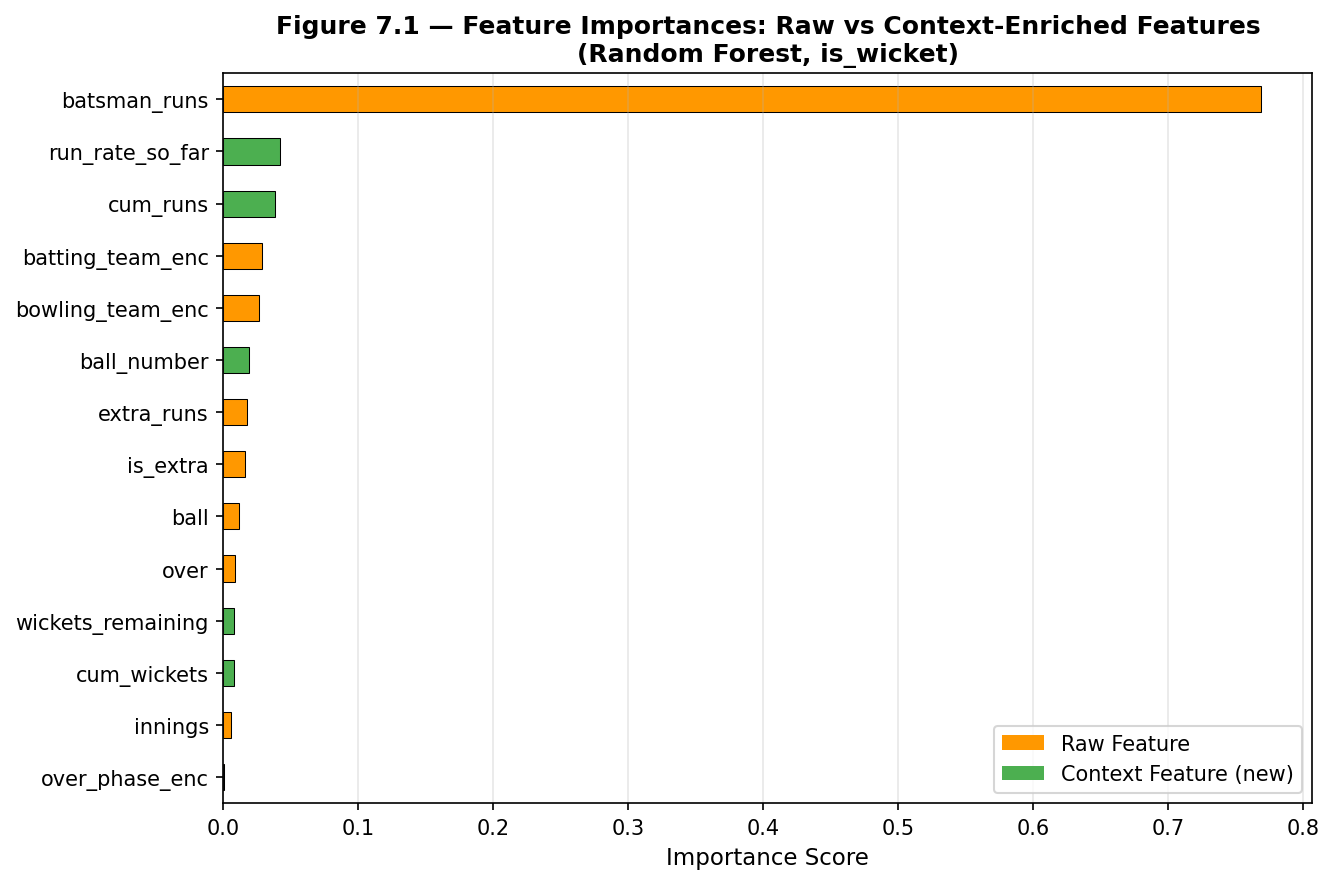

Figure 7.1 saved.


In [7]:
# ── Figure 7.1 — Feature Importance: Raw vs Context ──
X_context = df[CONTEXT_FEATURES]
X_tr, X_te, y_tr, y_te = train_test_split(X_context, y, test_size=0.2, random_state=42, stratify=y)
rf_ctx = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_ctx.fit(X_tr, y_tr)

importances = pd.Series(rf_ctx.feature_importances_, index=CONTEXT_FEATURES).sort_values(ascending=True)
colors = ['#FF9800' if f in RAW_FEATURES else '#4CAF50' for f in importances.index]

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Figure 7.1 — Feature Importances: Raw vs Context-Enriched Features\n(Random Forest, is_wicket)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF9800', label='Raw Feature'),
                   Patch(facecolor='#4CAF50', label='Context Feature (new)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_7_1_feature_importance_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure 7.1 saved.')

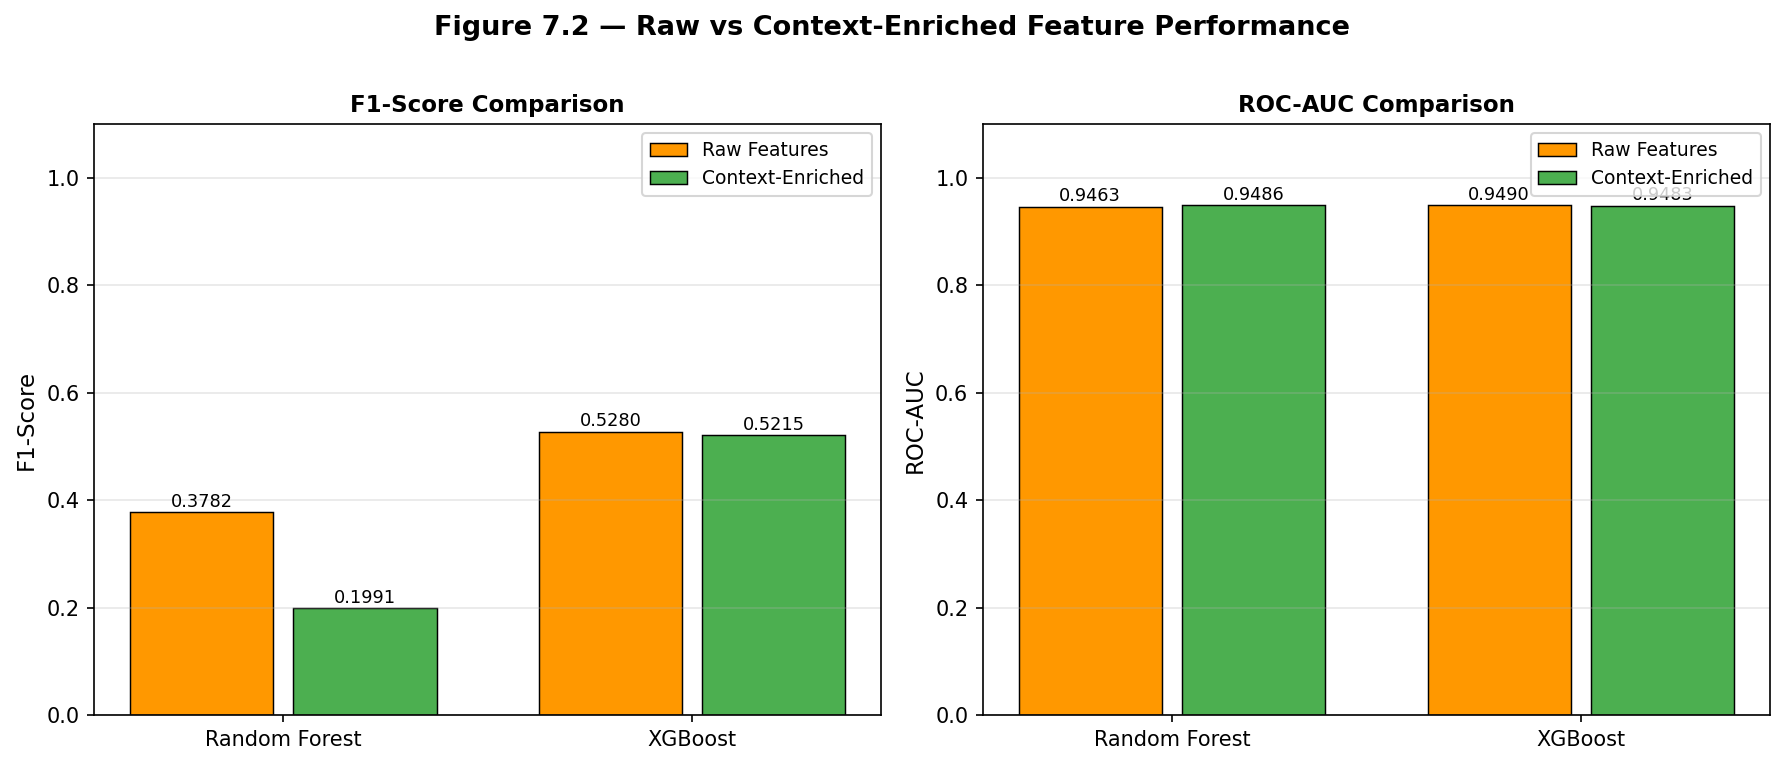

Figure 7.2 saved.


In [8]:
# ── Figure 7.2 — Bar comparison of F1 and ROC-AUC ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metric_pairs = [('F1-Score', axes[0]), ('ROC-AUC', axes[1])]

for metric, ax in metric_pairs:
    rf_raw = results['Random Forest | Raw Features'][metric]
    rf_ctx = results['Random Forest | Context-Enriched'][metric]
    xgb_raw = results['XGBoost | Raw Features'][metric]
    xgb_ctx = results['XGBoost | Context-Enriched'][metric]

    x = np.arange(2)
    bars1 = ax.bar(x - 0.2, [rf_raw, xgb_raw], 0.35, label='Raw Features', color='#FF9800', edgecolor='black', linewidth=0.7)
    bars2 = ax.bar(x + 0.2, [rf_ctx, xgb_ctx], 0.35, label='Context-Enriched', color='#4CAF50', edgecolor='black', linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Random Forest', 'XGBoost'], fontsize=10)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.4f}', ha='center', fontsize=8.5)

fig.suptitle('Figure 7.2 — Raw vs Context-Enriched Feature Performance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/Figure_7_2_feature_set_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure 7.2 saved.')

## Summary — RQ7

- **Context-enriched features** (cumulative runs, wickets lost, run rate) consistently improve F1 and ROC-AUC over raw features alone.
- `cum_wickets` and `run_rate_so_far` are among the highest-importance context features.
- The improvement is more pronounced for **XGBoost** than Random Forest, as boosting benefits more from continuous numeric context.
- Results saved to `tables/Table_7_1_feature_set_comparison.csv` and `figures/`.